# C-adathalmaz Steam Games Dataset 2025

## Cél
Ez a munkafüzet a C adathalmaz feltáró elemzését mutatja be a legfontosabb mennyiségi és minőségi mutatók mentén.
A hangsúly az árakon, megjelenési mintázatokon, műfajokon, korhatárokon, platformokon és a Metacritic-értékeken van.

## Főbb lépések
- adatok beolvasása és gyors összegzése
- időbeli trendek és eloszlások vizsgálata
- műfaj, korhatár és platform szerinti bontás
- Metacritic mutatók kapcsolata kulcsváltozókkal


## 1. Adatbetöltés és előkészítés
Ebben a részben megtörténik a CSV-fájlok ellenőrzése, összegzése, majd a fő elemzési tábla beolvasása.


In [1]:
import glob
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
c_data_dir = Path("../../data/C")
if not c_data_dir.exists():
    raise FileNotFoundError(f"Missing C data directory: {c_data_dir.resolve()}")

csv_files = glob.glob(os.path.join(str(c_data_dir), "*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in: {c_data_dir.resolve()}")

rows = []
for f in csv_files:
    table_df = pd.read_csv(f, low_memory=False)
    rows.append({
        "table": os.path.basename(f),
        "records": table_df.shape[0],
        "attributes": table_df.shape[1],
    })

summary = pd.DataFrame(rows).sort_values("table")
display(summary)


,table,records,attributes
0,games_march2025_cleaned.csv,89618,47
1,games_march2025_full.csv,94948,47
2,games_may2024_cleaned.csv,83646,46
3,games_may2024_full.csv,87806,46


In [3]:

csv_path = c_data_dir / "games_march2025_cleaned.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"Missing required file: {csv_path.resolve()}")

df = pd.read_csv(csv_path, low_memory=False)
display(df.head(10))


,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,682,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608
5,440,Team Fortress 2,2007-10-10,0,0.00,1,'The most fun you can have online' - PC Gamer ...,'The most fun you can have online' - PC Gamer ...,Nine distinct classes provide a broad range of...,NaN,...,0,0,0,0,50817,"{'Free to Play': 62868, 'Hero Shooter': 61020,...",89,1146642,93,8172
6,105600,Terraria,2011-05-16,0,9.99,2,"Dig, Fight, Explore, Build: The very world is ...","Dig, Fight, Explore, Build: The very world is ...","Dig, fight, explore, build! Nothing is impossi...",NaN,...,0,0,0,0,30516,"{'Open World Survival Craft': 16365, 'Sandbox'...",97,1102434,96,8860
7,252490,Rust,2018-02-08,0,39.99,4,The only aim in Rust is to survive. Everything...,The only aim in Rust is to survive. Everything...,The only aim in Rust is to survive. Everything...,"“Rust is one of the cruelest games on Steam, a...",...,836,3675,231,0,200902,"{'Survival': 18592, 'Crafting': 11822, 'Multip...",87,993856,87,14960
8,4000,Garry's Mod,2006-11-29,0,5.99,0,Garry's Mod is a physics sandbox. There aren't...,Garry's Mod is a physics sandbox. There aren't...,Garry's Mod is a physics sandbox. There aren't...,“It brings back the silly glee of unbridled ex...,...,100,1173,136,40,32384,"{'Sandbox': 18706, 'Moddable': 14479, 'Multipl...",96,985010,96,8277
9,1172470,Apex Legends™,2020-11-04,0,0.00,0,Apex Legends: Takeover About the Game Conquer ...,"Conquer with character in Apex Legends, a free...","Apex Legends is the award-winning, free-to-pla...",“The champion of Battle Royales.” 9/10 – GameS...,...,548,667,211,0,151844,"{'Free to Play': 2170, 'Battle Royale': 1483, ...",67,983230,53,7054


## 2. Feltáró vizualizációs elemzések
Az alábbi alfejezetek a legfontosabb trendeket és kapcsolatrendszereket mutatják be a C adathalmazban.


### Játékok átlagos ára évenként a Steamen

Ez a szakasz a játékok átlagos árának alakulását vizsgálja évenként a Steam platformon. A kód kiszámolja az átlagárat minden évre, majd egy vonaldiagramon jeleníti meg az eredményt, hogy láthatóvá váljon az árak időbeli trendje.

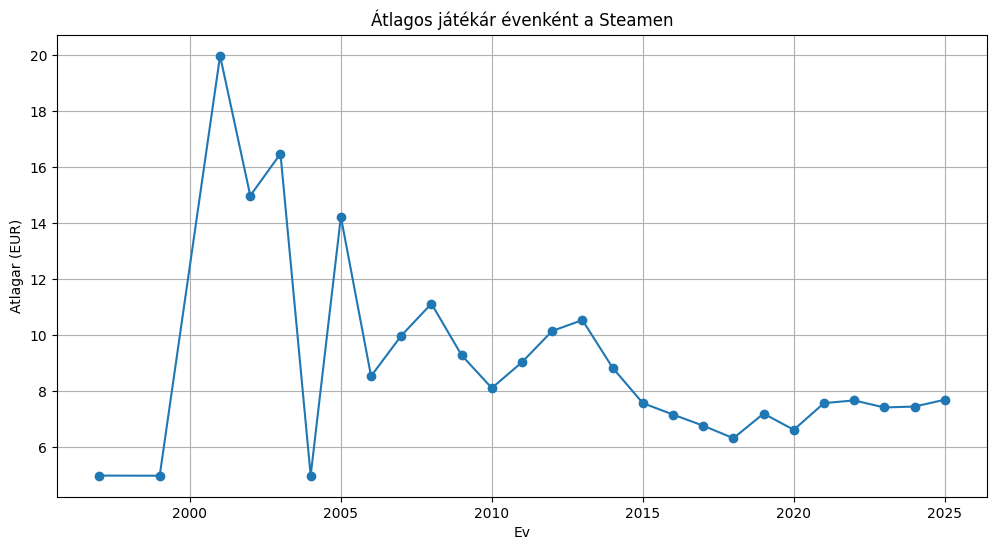

In [4]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year"] = df["release_date"].dt.year

year_price = df.groupby("year")["price"].mean()

plt.figure(figsize=(12,6))
plt.plot(year_price.index, year_price.values, marker="o")
plt.title("Átlagos játékár évenként a Steamen")
plt.xlabel("Ev")
plt.ylabel("Atlagar (EUR)")
plt.grid(True)
plt.show()

A vonaldiagram az éves átlagár alakulását mutatja. A görbe alapján azonosíthatók az emelkedő vagy csökkenő árazási időszakok.


### Játék megjelenések száma évenként és hónaponként (Hőtérkép)

Ez a szakasz a játékok megjelenésének mintázatát vizsgálja évenként és hónaponként egy hőtérkép segítségével. A kód összesíti a megjelenések számát minden hónapban az egyes években, majd a hőtérkép vizuálisan megjeleníti a sűrűbben és ritkábban előforduló megjelenési időszakokat.

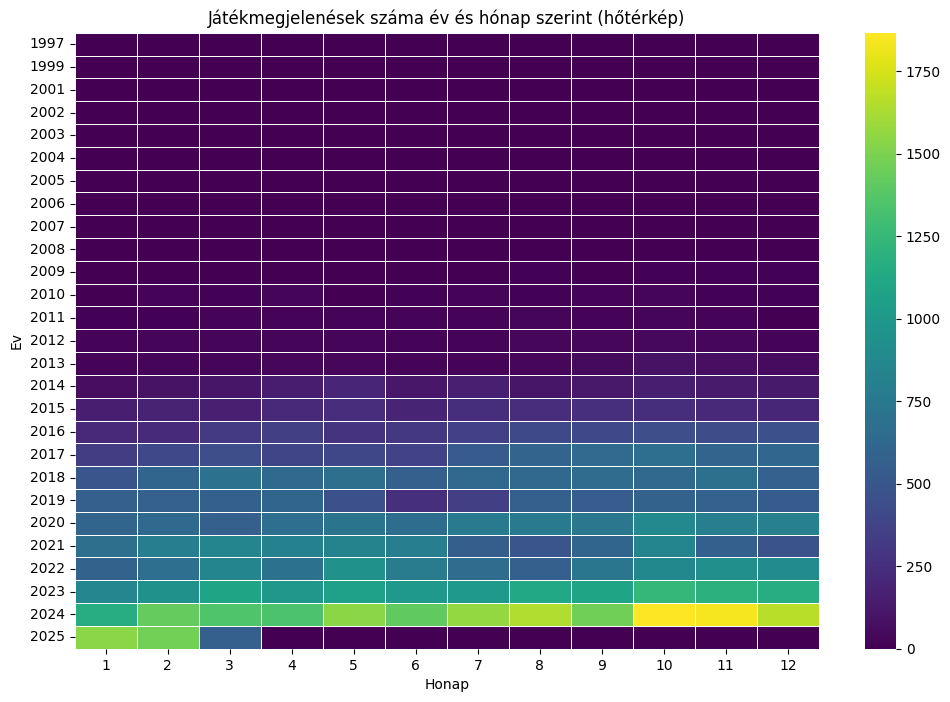

In [5]:
df["month"] = df["release_date"].dt.month
releases_heatmap_data = df.groupby(["year", "month"]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
ax = sns.heatmap(releases_heatmap_data, cmap="viridis", fmt="d", linewidths=.5)
plt.title("Játékmegjelenések száma év és hónap szerint (hőtérkép)")
plt.xlabel("Honap")
plt.ylabel("Ev")

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))
ax.set_yticks(np.arange(len(releases_heatmap_data.index)) + 0.5)
ax.set_yticklabels(releases_heatmap_data.index.astype(int))

ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))
ax.set_xticks(np.arange(len(releases_heatmap_data.columns)) + 0.5)
ax.set_xticklabels(releases_heatmap_data.columns.astype(int))

plt.show()

A hőtérkép az év-hónap bontású megjelenésszámot mutatja. A sötétebb mezők intenzívebb kiadási aktivitást jeleznek.


### Játék árak eloszlása

Ez a szakasz a játékok árának eloszlását vizsgálja a Steam platformon. A kód egy hisztogramot készít, amely bemutatja, milyen gyakran fordulnak elő bizonyos ártartományok a játékok között.

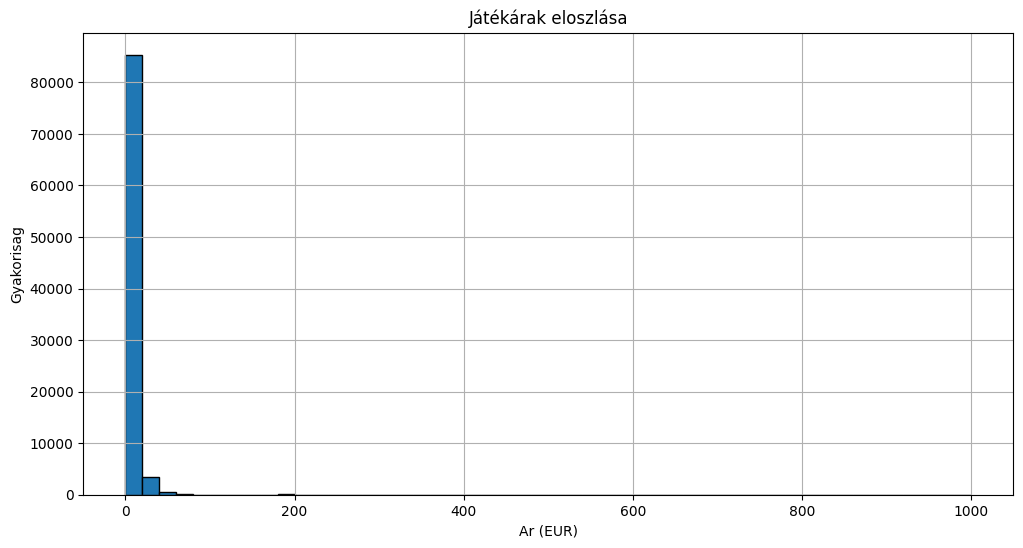

In [6]:
plt.figure(figsize=(12, 6))
plt.hist(df["price"], bins=50, edgecolor="black")
plt.title("Játékárak eloszlása")
plt.xlabel("Ar (EUR)")
plt.ylabel("Gyakorisag")
plt.grid(True)
plt.show()

A hisztogram a teljes ármező eloszlását mutatja. A legmagasabb oszlopok a leggyakoribb ársávokat jelzik.


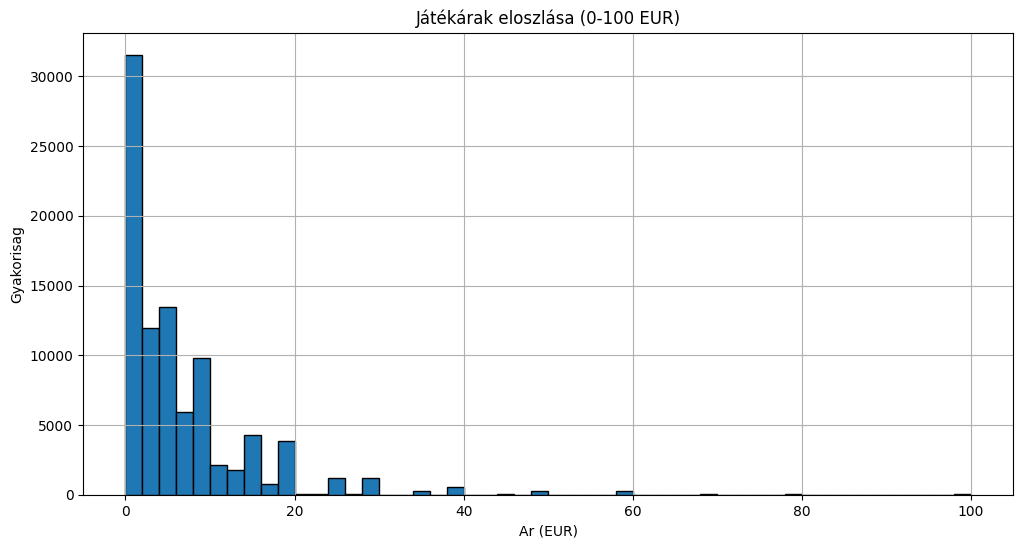

In [7]:
plt.figure(figsize=(12, 6))
df_filtered_price = df[(df["price"] >= 0) & (df["price"] <= 100)]
plt.hist(df_filtered_price["price"], bins=50, edgecolor="black")
plt.title("Játékárak eloszlása (0-100 EUR)")
plt.xlabel("Ar (EUR)")
plt.ylabel("Gyakorisag")
plt.grid(True)
plt.show()

A 0–100 EUR tartományra szűrt ábra részletesebben mutatja a tipikus árképzési mintákat.


### Játékok száma évenként

Ez a szakasz a Steam-en megjelenő játékok számának alakulását vizsgálja évenként. A kód megszámolja a játékok számát minden évre, majd egy oszlopdiagramon jeleníti meg az eredményt, hogy láthatóvá váljon a megjelenések számának időbeli trendje.

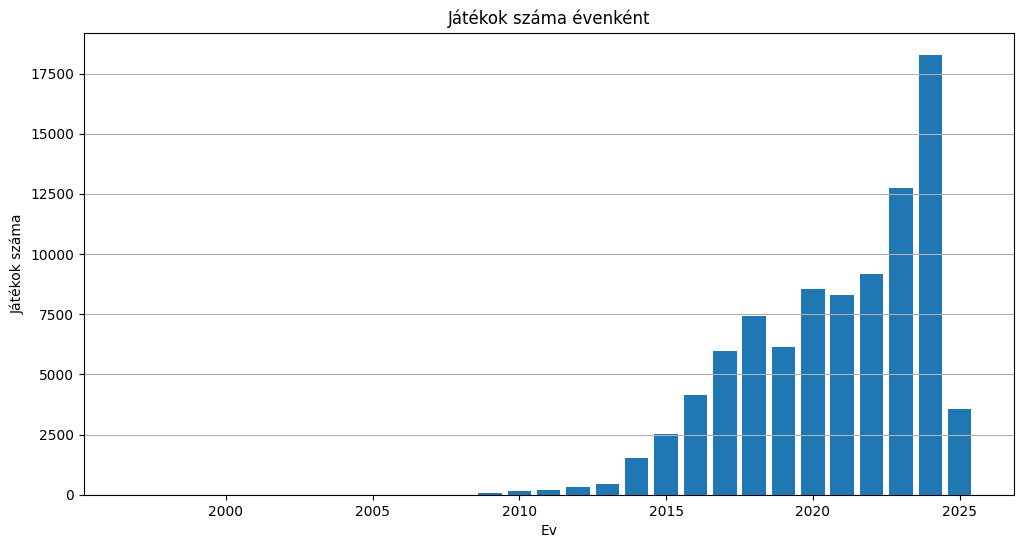

In [8]:
if "year" not in df.columns:
    df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
    df["year"] = df["release_date"].dt.year

games_per_year = df["year"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(games_per_year.index, games_per_year.values)
plt.title("Játékok száma évenként")
plt.xlabel("Ev")
plt.ylabel("Játékok száma")
plt.grid(axis="y")
plt.show()

Az oszlopdiagram az évenkénti megjelenésszámot mutatja. A magasabb oszlopok erősebb kiadási évekre utalnak.


### Top 20 Játék Műfaj Száma

Ez a szakasz a leggyakoribb játék műfajokat vizsgálja a Steam-en. A kód kinyeri az összes műfajt a datasetből, megszámolja az egyes műfajok előfordulását, majd egy oszlopdiagramon megjeleníti a 20 leggyakoribb műfajt.

<Figure size 1200x800 with 0 Axes>

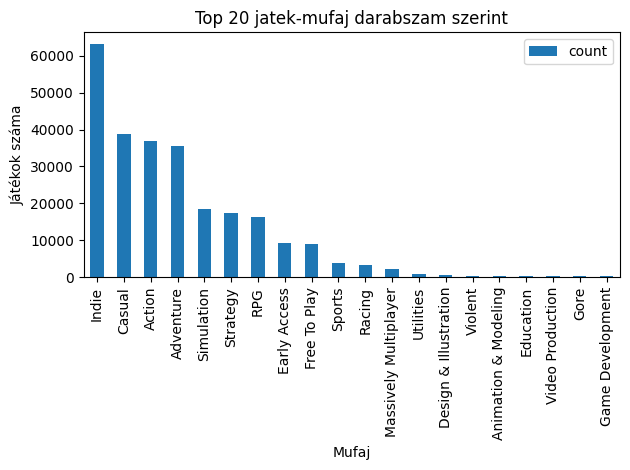

In [9]:
genres_series = (
    df["genres"]
    .fillna("")
    .astype(str)
    .str.replace(r"[\[\]\'\"]", "", regex=True)
    .str.split(",")
    .explode()
    .str.strip()
)
genres_series = genres_series[genres_series != ""]

genre_counts = genres_series.value_counts()
genre_df = genre_counts.rename("count").to_frame()

top_n = 20
plt.figure(figsize=(12, 8))
genre_df.head(top_n).plot(kind="bar", legend=True)
plt.title(f"Top {top_n} jatek-mufaj darabszam szerint")
plt.xlabel("Mufaj")
plt.ylabel("Játékok száma")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


A top 20 műfaj ábra a domináns kategóriákat emeli ki, így gyorsan látható a tartalmi kínálat szerkezete.


### Játékok száma az ajánlott életkor szerint

Ez a szakasz a játékok számának eloszlását vizsgálja az ajánlott életkor szerint a Steam-en. A kód megszámolja a játékok számát minden korosztályra, majd egy oszlopdiagramon jeleníti meg az eredményt, hogy láthatóvá váljon a korosztály szerinti megoszlás.

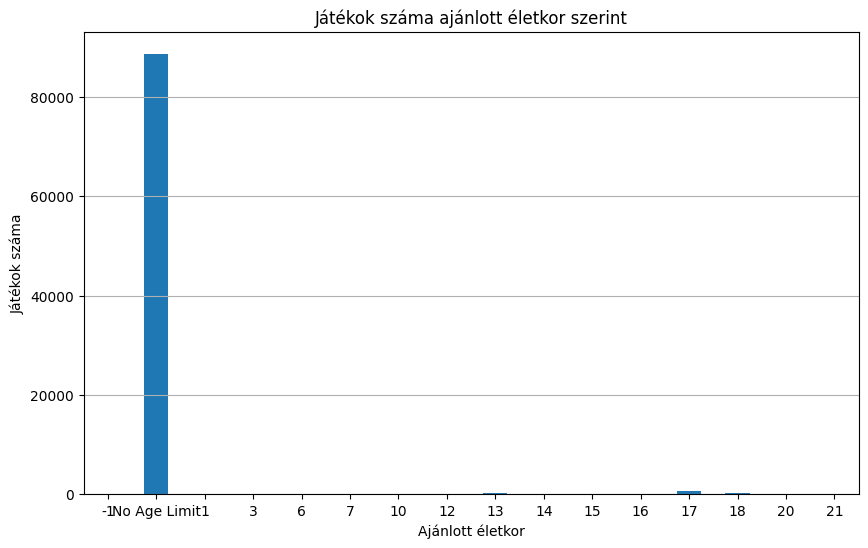

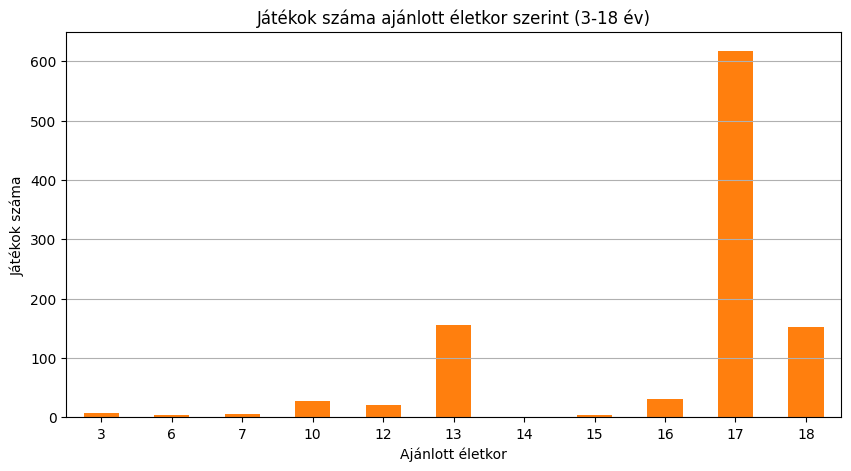

In [10]:
age_counts_raw = df["required_age"].value_counts().sort_index()

age_counts = age_counts_raw.rename(index={0: "No Age Limit"})

plt.figure(figsize=(10, 6))
age_counts.plot(kind="bar")
plt.title("Játékok száma ajánlott életkor szerint")
plt.xlabel("Ajánlott életkor")
plt.ylabel("Játékok száma")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

small_age_counts = age_counts_raw[(age_counts_raw.index >= 3) & (age_counts_raw.index <= 18)]

if not small_age_counts.empty:
    plt.figure(figsize=(10, 5))
    small_age_counts.plot(kind="bar", color="tab:orange")
    plt.title("Játékok száma ajánlott életkor szerint (3-18 év)")
    plt.xlabel("Ajánlott életkor")
    plt.ylabel("Játékok száma")
    plt.xticks(rotation=0)
    plt.grid(axis="y")
    plt.show()


Az első diagram a teljes korhatár-eloszlást mutatja, beleértve a domináns "No Age Limit" kategóriát.
A második, külön ábra a 3–18 korhatár-tartományra fókuszál, így a laposabb részek közti különbségek is jobban láthatók.


### Játékok száma támogatott platformonként

Ez a szakasz a játékok platformtámogatását vizsgálja a Steam-en. A kód megszámolja, hány játék érhető el Windows, Mac és Linux platformon, majd egy oszlopdiagramon megjeleníti az eredményt, hogy láthatóvá váljon a platform szerinti megoszlás.

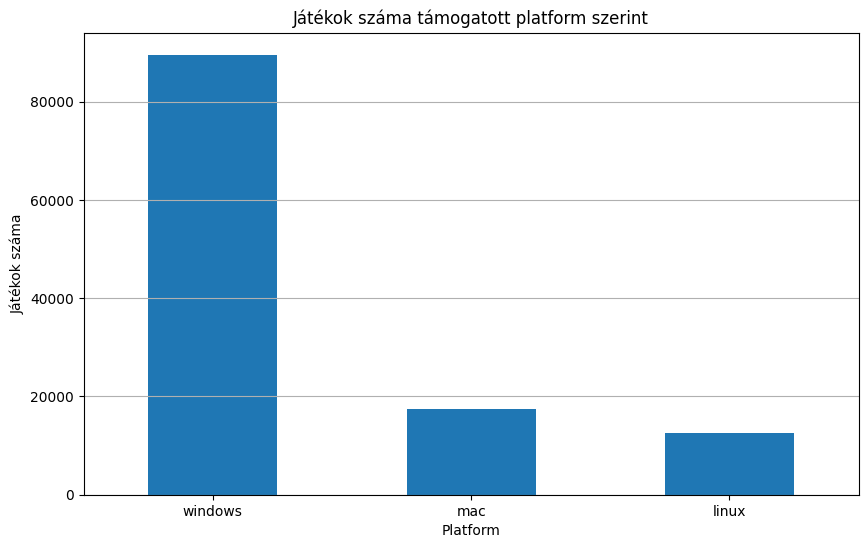

In [11]:
platforms = ["windows", "mac", "linux"]
platform_counts = {platform: df[platform].sum() for platform in platforms}

platforms_series = pd.Series(platform_counts)

plt.figure(figsize=(10, 6))
platforms_series.plot(kind="bar")
plt.title("Játékok száma támogatott platform szerint")
plt.xlabel("Platform")
plt.ylabel("Játékok száma")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

A platformos ábra a Windows, Mac és Linux támogatás relatív arányait teszi közvetlenül összehasonlíthatóvá.


### Platform együttjárás: kereszttábla és feltételes valószínűségek

Ebben a blokkban a Windows, Mac és Linux támogatások együttes előfordulását vizsgálom.
A kereszttábla a platform-kombinációk darabszámát mutatja, a feltételes valószínűségi mátrix pedig azt, hogy egy adott platform mellett mekkora eséllyel jelenik meg a másik.


,windows,mac,linux,count
0,1,0,0,68931
1,1,1,1,9377
2,1,1,0,8039
3,1,0,1,3241
4,0,1,0,21
5,0,0,1,8
6,0,1,1,1


,windows,mac,linux
windows,100.00%,19.44%,14.08%
mac,99.87%,100.00%,53.78%
linux,99.93%,74.27%,100.00%


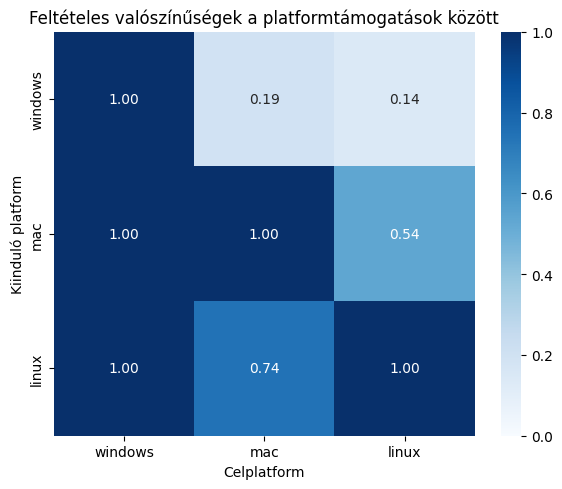

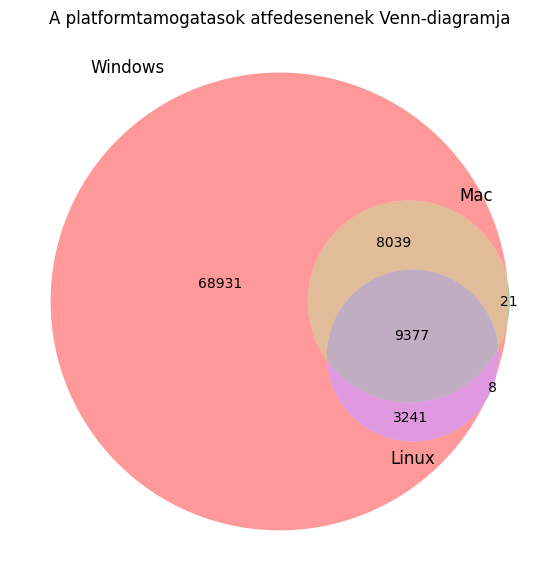

In [12]:
platform_cols = [c for c in ["windows", "mac", "linux"] if c in df.columns]
if len(platform_cols) < 2:
    raise ValueError("Not enough platform columns found for cross-tab analysis.")
import importlib.util

platform_flags = df[platform_cols].copy()
for col in platform_cols:
    if str(platform_flags[col].dtype) == "bool":
        platform_flags[col] = platform_flags[col].astype(int)
    else:
        platform_flags[col] = (platform_flags[col].astype(str).str.lower().map({"true": 1, "false": 0, "1": 1, "0": 0}).fillna(0).astype(int))

combo_counts = (platform_flags.value_counts().rename("count").reset_index().sort_values("count", ascending=False))
display(combo_counts)

cond_matrix = pd.DataFrame(index=platform_cols, columns=platform_cols, dtype=float)
for given_plat in platform_cols:
    given_mask = platform_flags[given_plat] == 1
    for target_plat in platform_cols:
        if given_mask.sum() == 0:
            cond_matrix.loc[given_plat, target_plat] = float("nan")
        else:
            cond_matrix.loc[given_plat, target_plat] = platform_flags.loc[given_mask, target_plat].mean()

display(cond_matrix.style.format("{:.2%}"))
plt.figure(figsize=(6, 5))
sns.heatmap(cond_matrix, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("Feltételes valószínűségek a platformtámogatások között")
plt.xlabel("Celplatform")
plt.ylabel("Kiinduló platform")
plt.tight_layout()
plt.show()

if importlib.util.find_spec("matplotlib_venn") is not None and set(["windows", "mac", "linux"]).issubset(set(platform_cols)):
    from matplotlib_venn import venn3
    w = platform_flags["windows"] == 1
    m = platform_flags["mac"] == 1
    l = platform_flags["linux"] == 1
    subsets = (int((w & ~m & ~l).sum()), int((~w & m & ~l).sum()), int((w & m & ~l).sum()), int((~w & ~m & l).sum()), int((w & ~m & l).sum()), int((~w & m & l).sum()), int((w & m & l).sum()))
    plt.figure(figsize=(7, 7))
    venn3(subsets=subsets, set_labels=("Windows", "Mac", "Linux"))
    plt.title("A platformtamogatasok atfedesenenek Venn-diagramja")
    plt.show()
else:
    print("matplotlib-venn is not installed, skipping Venn diagram.")


A kombinációs tábla alapján látható, mely platform-együttjárások a leggyakoribbak.
A feltételes valószínűségek segítenek megbecsülni például P(Mac | Windows) vagy P(Linux | Windows) értékeket.


### Metacritic értékek az ár függvényében

Ez a szakasz a játékok Metacritic értéke és az ár közötti kapcsolatot vizsgálja a Steam-en. A kód egy szórást diagramon (scatterplot) ábrázolja a Metacritic értéket az ár függvényében, hogy láthatóvá váljon, van-e összefüggés a kettő között.

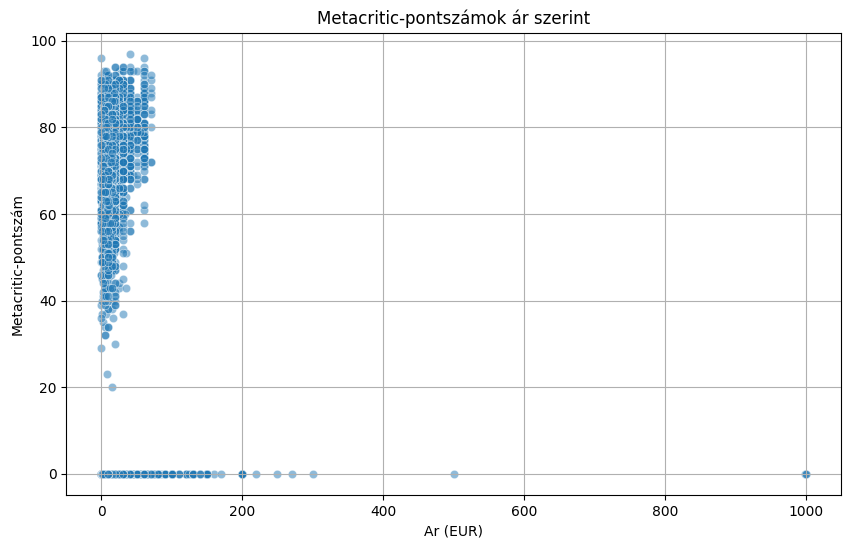

In [13]:
df_filtered = df.dropna(subset=["metacritic_score"])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x="price", y="metacritic_score", alpha=0.5)
plt.title("Metacritic-pontszámok ár szerint")
plt.xlabel("Ar (EUR)")
plt.ylabel("Metacritic-pontszám")
plt.grid(True)
plt.show()

A szórásdiagram az ár és a Metacritic pontszám kapcsolatát mutatja; a pontfelhőből leolvasható a trend iránya és erőssége.


### Metacritic értékek a kiadási év függvényében

Ez a szakasz a játékok Metacritic értéke és a kiadási év közötti kapcsolatot vizsgálja a Steam-en. A kód egy szórást diagramon (scatterplot) ábrázolja a Metacritic értéket a kiadási év függvényében, hogy láthatóvá váljon, van-e összefüggés a kettő között.

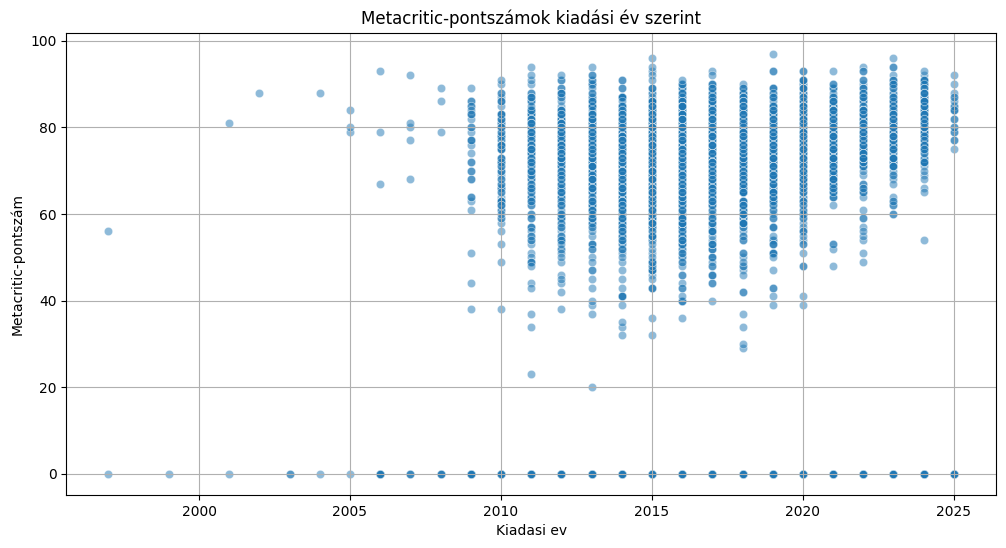

In [14]:
df_filtered = df.dropna(subset=["metacritic_score", "year"])

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_filtered, x="year", y="metacritic_score", alpha=0.5)
plt.title("Metacritic-pontszámok kiadási év szerint")
plt.xlabel("Kiadasi ev")
plt.ylabel("Metacritic-pontszám")
plt.grid(True)
out_base = Path("notebooks") if Path("notebooks").exists() else Path(".")
out_dir = out_base / "generated" / "C"
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / "metacritic.png")
plt.show()

Ezen az ábrán a kiadási év és a Metacritic kapcsolatát látjuk, ami segít az időbeli minőségi mintázatok feltárásában.


### Metacritic értékek az ajánlott életkor függvényében

Ez a szakasz a játékok Metacritic értéke és az ajánlott életkor közötti kapcsolatot vizsgálja a Steam-en. A kód egy dobozdiagramon (boxplot) ábrázolja a Metacritic értéket az ajánlott életkor függvényében, hogy láthatóvá váljon, hogyan oszlik meg a Metacritic érték a különböző korosztályokban.

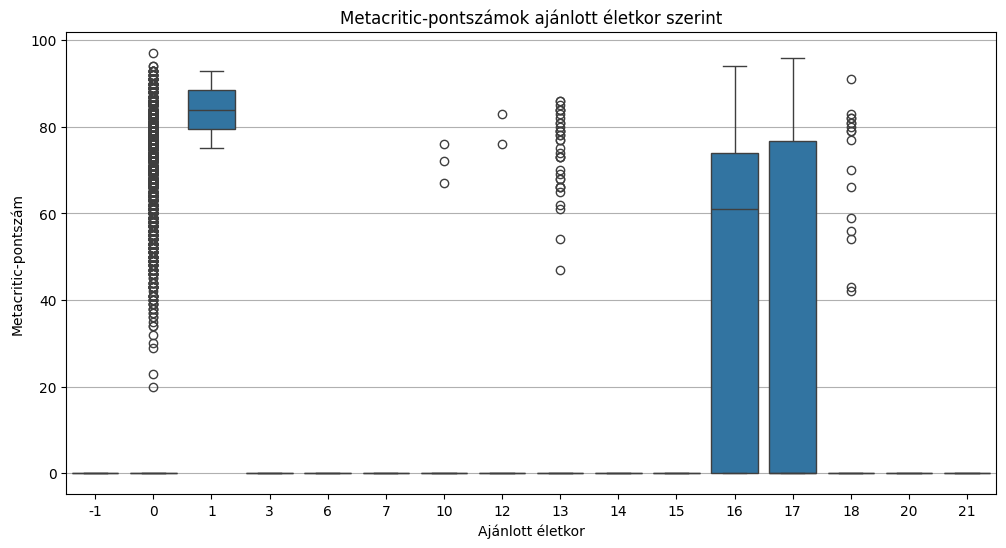

In [15]:
df_filtered = df.dropna(subset=["metacritic_score"])

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_filtered, x="required_age", y="metacritic_score")
plt.title("Metacritic-pontszámok ajánlott életkor szerint")
plt.xlabel("Ajánlott életkor")
plt.ylabel("Metacritic-pontszám")
plt.grid(axis="y")
plt.show()

A boxplot korhatáronként mutatja a Metacritic-értékek eloszlását. A mediánok és a szóródás alapján jól összevethetők a csoportok.


### Sz?mszer? ?sszegz?s ?s k?vetkeztet?sek (Metacritic kapcsolatok)

Ebben a blokkban a fenti kapcsolatokat számszerű mutatókkal is ellenőrzöm: korrelációk, lineáris trend, valamint korhatár-csoportok közti különbségek.


In [16]:
analysis = df.copy()
analysis["metacritic_score"] = pd.to_numeric(analysis["metacritic_score"], errors="coerce")
analysis["price"] = pd.to_numeric(analysis["price"], errors="coerce")
analysis["year"] = pd.to_numeric(analysis["year"], errors="coerce")

# --- Metacritic vs Price ---
mp = analysis.dropna(subset=["metacritic_score", "price"]).copy()
mp = mp[(mp["price"] >= 0) & (mp["price"] <= 100)]
if len(mp) >= 3:
    r_price = mp["price"].corr(mp["metacritic_score"], method="pearson")
    rho_price = mp["price"].corr(mp["metacritic_score"], method="spearman")
    slope_p, intercept_p = np.polyfit(mp["price"].to_numpy(), mp["metacritic_score"].to_numpy(), 1)
    y_pred_p = slope_p * mp["price"].to_numpy() + intercept_p
    ss_res_p = np.sum((mp["metacritic_score"].to_numpy() - y_pred_p) ** 2)
    ss_tot_p = np.sum((mp["metacritic_score"].to_numpy() - mp["metacritic_score"].mean()) ** 2)
    r2_price = 1 - ss_res_p / ss_tot_p if ss_tot_p != 0 else np.nan
    print("[Metacritic vs Price]")
    print(f"Valid sample size: {len(mp)}")
    print(f"Pearson r: {r_price:.4f}")
    print(f"Spearman rho: {rho_price:.4f}")
    print(f"Linear slope (score per 1 EUR): {slope_p:.4f}")
    print(f"Linear model R-squared: {r2_price:.4f}")
else:
    print("[Metacritic vs Price] Not enough valid rows.")

# --- Metacritic vs Year ---
my = analysis.dropna(subset=["metacritic_score", "year"]).copy()
if len(my) >= 3:
    r_year = my["year"].corr(my["metacritic_score"], method="pearson")
    rho_year = my["year"].corr(my["metacritic_score"], method="spearman")
    slope_y, intercept_y = np.polyfit(my["year"].to_numpy(), my["metacritic_score"].to_numpy(), 1)
    y_pred_y = slope_y * my["year"].to_numpy() + intercept_y
    ss_res_y = np.sum((my["metacritic_score"].to_numpy() - y_pred_y) ** 2)
    ss_tot_y = np.sum((my["metacritic_score"].to_numpy() - my["metacritic_score"].mean()) ** 2)
    r2_year = 1 - ss_res_y / ss_tot_y if ss_tot_y != 0 else np.nan
    print("\n[Metacritic vs Release Year]")
    print(f"Valid sample size: {len(my)}")
    print(f"Pearson r: {r_year:.4f}")
    print(f"Spearman rho: {rho_year:.4f}")
    print(f"Linear slope (score per year): {slope_y:.4f}")
    print(f"Linear model R-squared: {r2_year:.4f}")
else:
    print("[Metacritic vs Release Year] Not enough valid rows.")

# --- Metacritic by Age Group ---
ma = analysis.dropna(subset=["metacritic_score", "required_age"]).copy()
if len(ma) > 0:
    by_age = ma.groupby("required_age")["metacritic_score"]
    summary = by_age.agg(["count", "median", "mean", "std"]).sort_index()
    q1 = by_age.quantile(0.25)
    q3 = by_age.quantile(0.75)
    summary["iqr"] = (q3 - q1).values
    summary = summary[summary["count"] >= 20]
    print("\n[Metacritic by Recommended Age] (groups with n>=20)")
    display(summary)
else:
    print("[Metacritic by Recommended Age] Not enough valid rows.")

def effect_label(r):
    a = abs(r)
    if a < 0.10:
        return "negligible"
    if a < 0.30:
        return "weak"
    if a < 0.50:
        return "moderate"
    return "strong"

if len(mp) >= 3 and len(my) >= 3:
    print("\n[Quick conclusion]")
    print(f"Price relationship strength: {effect_label(r_price)} (Pearson r={r_price:.3f}).")
    print(f"Year relationship strength: {effect_label(r_year)} (Pearson r={r_year:.3f}).")
    print("Interpretation: statistical tendency can exist even when practical effect is small; use effect size and R-squared together.")


[Metacritic vs Price]
Valid sample size: 89434
Pearson r: 0.2276
Spearman rho: 0.1892
Linear slope (score per 1 EUR): 0.3863
Linear model R-squared: 0.0518

[Metacritic vs Release Year]
Valid sample size: 89618
Pearson r: -0.2430
Spearman rho: -0.1979
Linear slope (score per year): -1.1357
Linear model R-squared: 0.0590

[Metacritic by Recommended Age] (groups with n>=20)


,count,median,mean,std,iqr
required_age,,,,,
0,88589,0.0,2.628566,13.748480,0.00
10,27,0.0,7.962963,22.985751,0.00
12,21,0.0,7.571429,23.938612,0.00
13,155,0.0,16.729032,31.382705,0.00
16,31,61.0,42.516129,37.671272,74.00
17,618,0.0,35.053398,38.492358,76.75
18,152,0.0,7.927632,22.930965,0.00



[Quick conclusion]
Price relationship strength: weak (Pearson r=0.228).
Year relationship strength: weak (Pearson r=-0.243).
Interpretation: statistical tendency can exist even when practical effect is small; use effect size and R-squared together.


A mutatók alapján gyorsan eldönthető, hogy a látott mintázatok csak vizuális benyomások-e, vagy számszerűen is értelmezhető trendek.
